# Hälsostudie

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=3)
pd.set_option("display.precision", 3)

In [2]:
data = pd.read_csv("health_study_dataset.csv")
display(data.head())
display(data.info())
display(data.describe())

dup_mask = data.duplicated(keep=False)

print("Antal dubletter", dup_mask.sum())
data[dup_mask].head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


None

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,400.500,49.426,171.849,73.413,149.179,4.929,0.059
std,231.084,14.501,9.804,13.685,12.793,0.848,0.235
min,1.000,18.000,144.400,33.700,106.800,2.500,0.000
25%,200.750,39.000,164.775,64.800,140.900,4.328,0.000
50%,400.500,50.000,171.350,73.200,149.400,4.970,0.000
75%,600.250,59.000,178.925,82.600,157.600,5.482,0.000
max,800.000,90.000,200.400,114.400,185.900,7.880,1.000


Antal dubletter 0


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease


In [3]:
clean = data.dropna().copy()

clean.columns = (clean.columns
            .str.strip()
            .str.replace(" ", "_")
            .str.lower())

#Även kolla na m.m.

In [4]:
columns = ["age", "weight", "height", "systolic_bp", "cholesterol"]

summary_stats = (
    clean[columns]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

summary_stats

# Ta bort # och smalare kolumner

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


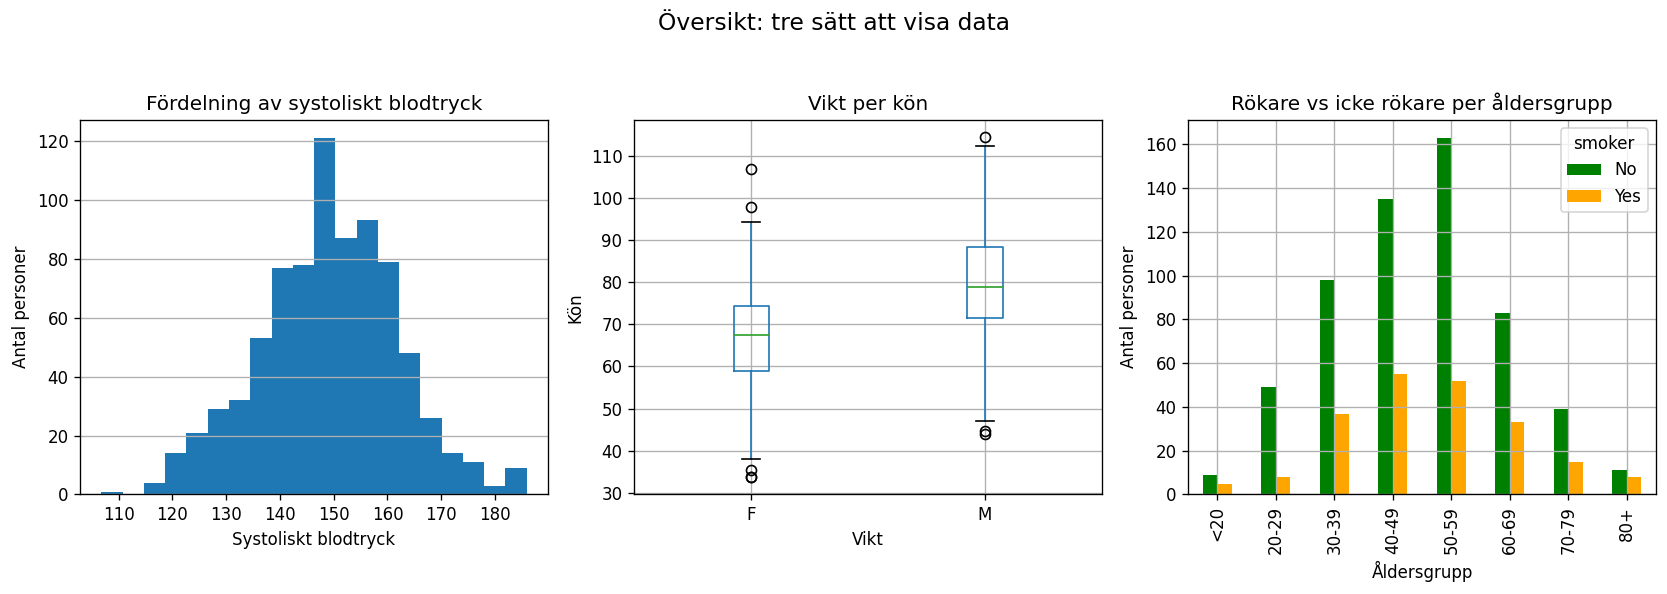

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=False, sharey=False) 

axes[0].hist(clean.systolic_bp.dropna(), bins=20)
axes[0].set_title("Fördelning av systoliskt blodtryck")
axes[0].set_xlabel("Systoliskt blodtryck")
axes[0].set_ylabel("Antal personer")
axes[0].grid(True, axis="y")
axes[0].xaxis.grid(False)  

clean.boxplot(column="weight", by="sex", ax=axes[1])
axes[1].set_title("Vikt per kön")
axes[1].set_xlabel("Vikt")
axes[1].set_ylabel("Kön")
axes[1].grid(True, axis="y")

bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
age_bins = pd.cut(clean["age"], bins=bins, labels=labels, right=False)
cross = pd.crosstab(age_bins, clean["smoker"])

cross.plot(kind="bar", ax=axes[2], color=["green", "orange"])
axes[2].set_title("Rökare vs icke rökare per åldersgrupp")
axes[2].set_xlabel("Åldersgrupp")
axes[2].set_ylabel("Antal personer")
axes[2].grid(True, axis="y")

fig.suptitle("Översikt: tre sätt att visa data", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()


In [6]:
andel_sjuka = (clean["disease"].sum() / len(clean))

np.random.seed(123)
n = 1000

simulerat_sjuka = np.random.choice([0, 1], size=n, p=[1-andel_sjuka, andel_sjuka])
andel_sjuka_simulerat = simulerat_sjuka.sum() / n

print(f"Andel observerat sjuka: {andel_sjuka*100:.1f}%")
print(f"Andel simulerat sjuka: {andel_sjuka_simulerat*100:.1f}%")


Andel observerat sjuka: 5.9%
Andel simulerat sjuka: 6.6%


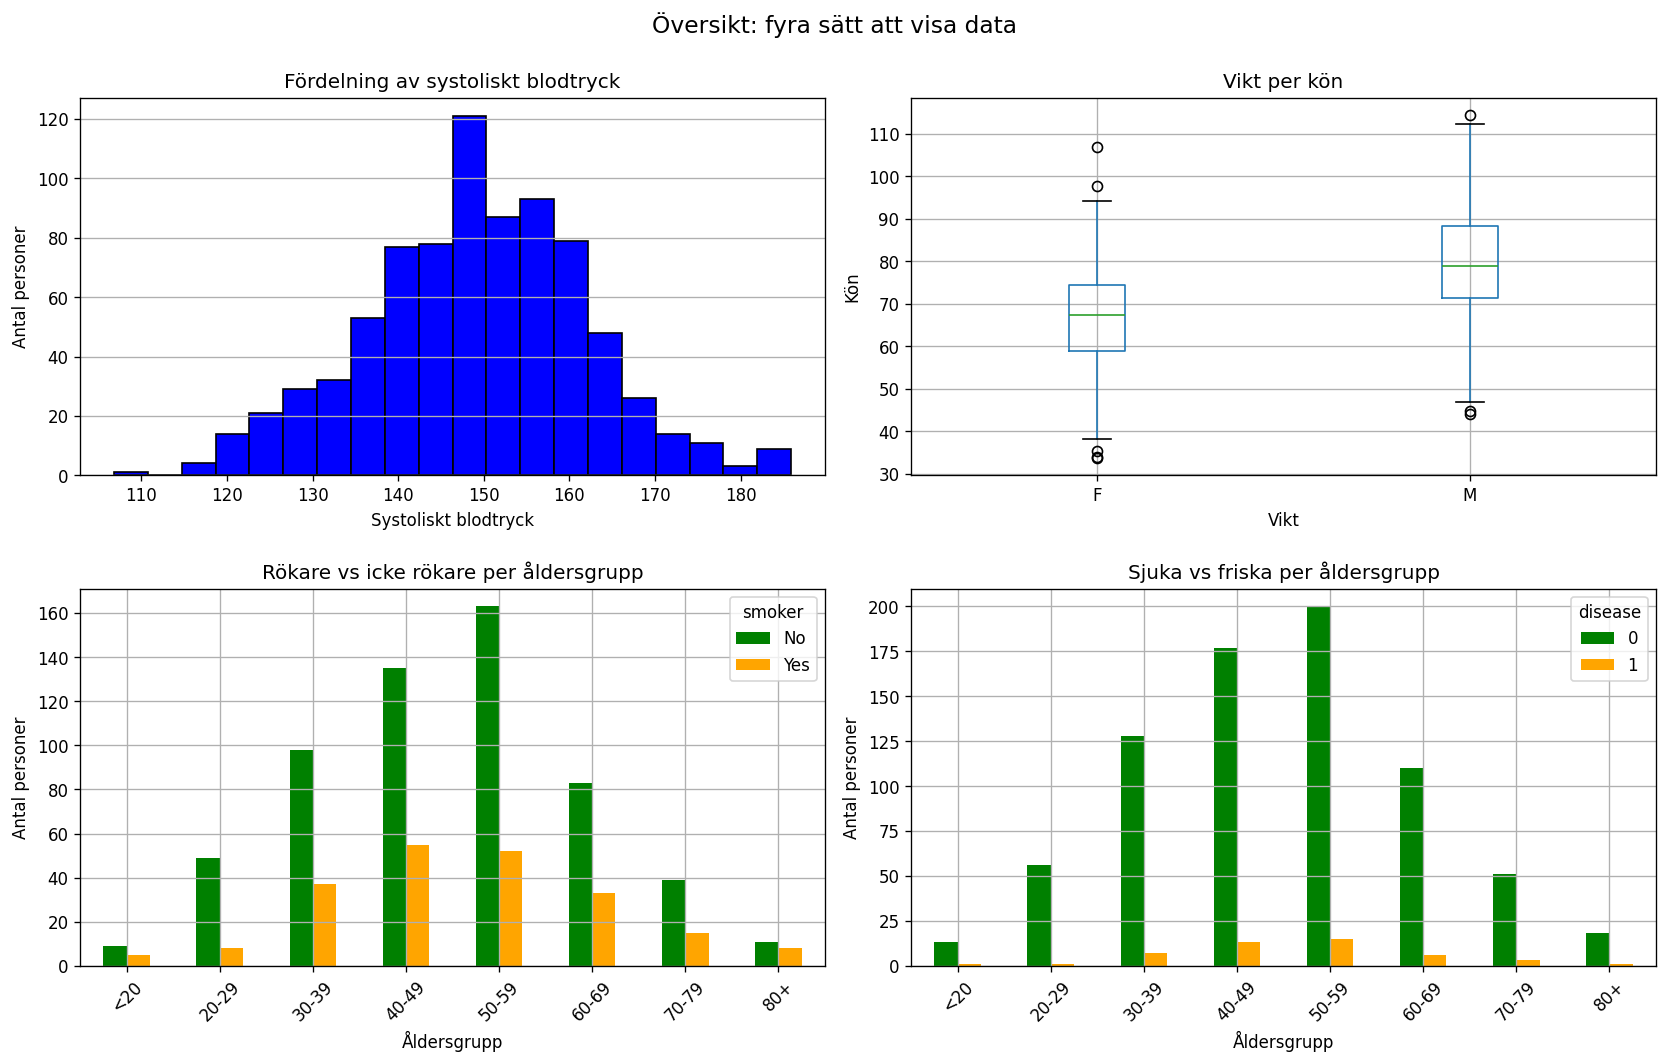

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False, sharey=False) 

axes[0,0].hist(clean.systolic_bp.dropna(), bins=20, color="blue", edgecolor="black")
axes[0,0].set_title("Fördelning av systoliskt blodtryck")
axes[0,0].set_xlabel("Systoliskt blodtryck")
axes[0,0].set_ylabel("Antal personer")
axes[0,0].grid(True, axis="y")
axes[0,0].xaxis.grid(False)  

clean.boxplot(column="weight", by="sex", ax=axes[0,1])
axes[0,1].set_title("Vikt per kön")
axes[0,1].set_xlabel("Vikt")
axes[0,1].set_ylabel("Kön")
axes[0,1].grid(True, axis="y")

bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
age_bins = pd.cut(clean["age"], bins=bins, labels=labels, right=False)
cross = pd.crosstab(age_bins, clean["smoker"])

cross.plot(kind="bar", ax=axes[1,0], color=["green", "orange"])
axes[1,0].set_title("Rökare vs icke rökare per åldersgrupp")
axes[1,0].set_xlabel("Åldersgrupp")
axes[1,0].set_ylabel("Antal personer")
axes[1,0].grid(True, axis="y")
plt.setp(axes[1,0].get_xticklabels(), rotation=45)

bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
age_bins = pd.cut(clean["age"], bins=bins, labels=labels, right=False)
cross = pd.crosstab(age_bins, clean["disease"])

cross.plot(kind="bar", ax=axes[1,1], color=["green", "orange"])
axes[1,1].set_title("Sjuka vs friska per åldersgrupp")
axes[1,1].set_xlabel("Åldersgrupp")
axes[1,1].set_ylabel("Antal personer")
axes[1,1].grid(True, axis="y")
plt.setp(axes[1,1].get_xticklabels(), rotation=45)

fig.suptitle("Översikt: fyra sätt att visa data", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.9, hspace=0.3)
plt.show()

In [8]:
# Normalapproximation - OBS städa namnen t.ex. nmean istället för mean_x för att matcha bmean

from math import sqrt
 
def ci_mean_normal (x, confidedence=0.95):
    """
    95%-CI för medel med normal-approximationen:
    medel ± 1.96 * (s / sqrt(n))
    """
    x = np.asarray(x, dtype=float)
    mean_x = float(np.mean(x))
    s = float(np.std(x, ddof=1))
    n = len(x)

    z_critical = 1.96
    half_width = z_critical * s / sqrt(n)
    lo, hi = mean_x - half_width, mean_x + half_width
    return lo, hi, mean_x, s, n

lo, hi, mean_x, s, n = ci_mean_normal(clean["systolic_bp"])

print(f"Normal medelvärde: {mean_x:.10f}")
print(f"Standardavvikelse: {s:.2f}")
print(f"Normal 95% konfidensintervall: [{lo:.2f}, {hi:.2f}]")
print(f"Antal observationer, n: {n}")

Normal medelvärde: 149.1786250000
Standardavvikelse: 12.79
Normal 95% konfidensintervall: [148.29, 150.07]
Antal observationer, n: 800


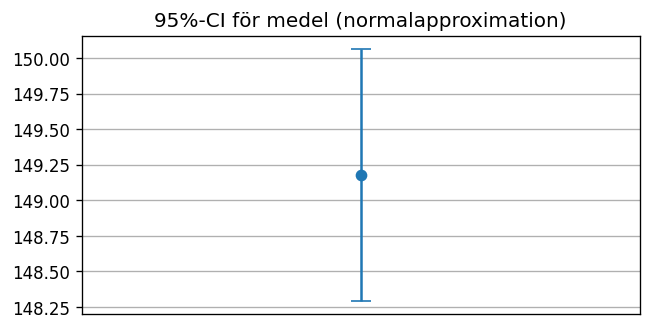

In [9]:
fig, ax = plt.subplots(figsize=(6,3))
ax.errorbar([0], [mean_x], yerr=[[mean_x - lo], [hi - mean_x]], fmt="o", capsize=6)
ax.set_xticks([])
ax.grid(True, axis="y")
ax.set_title("95%-CI för medel (normalapproximation)")
plt.show()

In [10]:
# Bootstrap

def ci_mean_bootstrap(x, B=5000, confidence=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    boot_means = np.empty(B)
    for b in range(B):
        boot_sample = np.random.choice(x, size=n, replace=True)
        boot_means[b] = np.mean(boot_sample)

    alpha = (1 - confidence) / 2 
    lo, hi= np.percentile(boot_means, [100*alpha, 100*(1-alpha)])
    return float(lo), float(hi), float(np.mean(x))

x = clean["systolic_bp"]

blo, bhi, bmean = ci_mean_bootstrap(x, B=5000)

print(f"Bootstrap medelvärde: {bmean:.10f}")
print(f"Bootstrap 95% konfidensintervall: [{blo:.2f}, {bhi:.2f}]")

Bootstrap medelvärde: 149.1786250000
Bootstrap 95% konfidensintervall: [148.27, 150.05]


#### Konfidensintervall för medelvärde
Normal medelvärde: 149.1786250000  
Bootstrap medel: 149.1786250000  
Normal 95% konfidensintervall: [148.29, 150.07]  
Bootstrap 95% konfidensintervall: [148.31, 150.04]  

Medelvärdet och konfidensintervallet med normalapproximation och Bootstrap är mycket lika vilket indikerar att data för systoliskt blodtryck är normalfördelad.

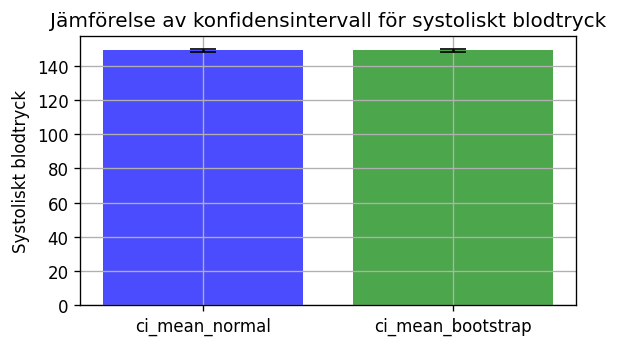

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))

methods = ["ci_mean_normal", "ci_mean_bootstrap"]
means = [mean_x, bmean]
lower = [mean_x - lo, bmean - blo]
upper = [hi - mean_x, bhi - bmean]

ax.bar(methods, means, yerr=[lower, upper],
       capsize=8, color=["blue", "green"],alpha=0.7)
ax.set_title("Jämförelse av konfidensintervall för systoliskt blodtryck")
ax.set_ylabel("Systoliskt blodtryck")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [12]:
# Hypotesprövning
# Testa hypotesen: ”Rökare har högre medel-blodtryck än icke-rökare.”
# Använd en av metoderna vi gått igenom (t.ex. bootstrap eller enkel t-test-funktion).
# Förklara kort resultatet i en markdown-ruta.
# Gör en simulering för att undersöka hur säkert ditt hypotes­test är (t.ex. hur ofta testet hittar en skillnad när den finns → power).

bp_rökare = clean.loc[clean["smoker"].str.lower() == "no", "systolic_bp"]
bp_ickerökare = clean.loc[clean["smoker"].str.lower() == "yes", "systolic_bp"]

mean_bp_rökare = bp_rökare.mean()
mean_bp_ickerökare = bp_ickerökare.mean()

std_bp_rökare = bp_rökare.std()
std_bp_ickerökare = bp_ickerökare.std()

t_stat, p_val = stats.ttest_ind(bp_ickerökare, bp_rökare, equal_var=True)
t_stat_w, p_val_w = stats.ttest_ind(bp_ickerökare, bp_rökare, equal_var=False)

print("Medelvärden blodtryck:")
print(f"Rökare: {mean_bp_rökare:.2f} ± {std_bp_rökare:.2f}")
print(f"Icke-rökare: {mean_bp_ickerökare:.2f} ± {std_bp_ickerökare:.2f}\n")

print("T-testresultat:")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

Medelvärden blodtryck:
Rökare: 149.05 ± 12.63
Icke-rökare: 149.52 ± 13.27

T-testresultat:
Standard t-test: t = 0.461, p = 0.6450
Welch t-test: t = 0.450, p = 0.6527


#### T-test
T-testen visar att det inte finns någon signifikant skillnad mellan medelvärdet av systoliskt blodtryck mellan gruppen rökare och icke-rökare.  
Både t-test och Welch-test visar liknande resultat vilket stödjer att detta.

In [13]:
# Beräkning av Cohen's d

var_rökare = bp_rökare.var(ddof=1)
var_ickerökare = bp_ickerökare.var(ddof=1)

sp = np.sqrt(
    ((len(bp_rökare)-1)*var_rökare + (len(bp_ickerökare)-1)*var_ickerökare)
    / (len(bp_rökare) + len(bp_ickerökare) - 2))

cohens_d = (mean_bp_rökare - mean_bp_ickerökare) / sp

print(f"Cohen's d: {cohens_d:.4f}")


Cohen's d: -0.0369


#### Cohen's d

Cohen's d är under 0,2 vilket visar på en liten effekt och stödjer t-testets resultat att det är en lite skillnd mellan gruppernas meddelvärden.
D är negativs vilket indikerar att icke-rökare har ett lägre systoliskt blodtryck än rökare. Då skillnaden är lite och effekten liten så går det inte att säga utifrån datan att rökning har en påverkan på systiloskt blodtryck.

In [14]:
# Power-simulering

np.random.seed(123)

d = cohens_d
sd = sp
mean_diff = d * sd

n_sim = 8000
n_rökare = len(bp_rökare)
n_ickerökare = len(bp_ickerökare)
alpha = 0.05 
hits = 0 

for i in range(n_sim):
    sim_rökare = np.random.normal(mean_bp_rökare, sd, n_rökare)
    sim_ickerökare = np.random.normal(mean_bp_ickerökare, sd, n_ickerökare)
    _, p = stats.ttest_ind(sim_rökare, sim_ickerökare, equal_var=False)
    if p < alpha:
        hits += 1

power = hits / n_sim
print(f"Antal hits: {hits}")
print(f"Power ≈ {power:.3f}")

# Power beror alltså på urvalsstorleken, men också på effektstorleken. https://spssakuten.com/2012/11/11/guide-statistisk-power-och-urvalsstorlek-i-experimentell-design/


Antal hits: 639
Power ≈ 0.080
